In [1]:
# Base.invokelatest(include, localpath("src/Deborah.jl"))
# import .Deborah
using Revise
import Deborah; flush(stdout); flush(stderr)

[ Info: lib_lightgbm found in system dirs!
┌ Info: lib_lightgbm found in system dirs!
└ @ LightGBM /Users/benjamin/.julia/packages/LightGBM/xQZ0z/src/LightGBM.jl:32


In [2]:
const PROJECT_ROOT = joinpath(homedir(), "work", "Deborah.jl")
function localpath(relpath::AbstractString)
    return joinpath(PROJECT_ROOT, relpath)
end

work = "nf4_clover_wilson_finiteT"

ns = 12
nt = 4
b = "1.60"

basepath = localpath(work)
prefix   = "L$(ns)T$(nt)b$(b)"

ensembles = filter(entry -> isdir(joinpath(basepath, entry)),
                   readdir(basepath; join=true)) .|> basename |>
            x -> filter(e -> startswith(e, prefix), x)

raw_paths = [localpath(joinpath(work, ens)) for ens in ensembles]

jobid = nothing

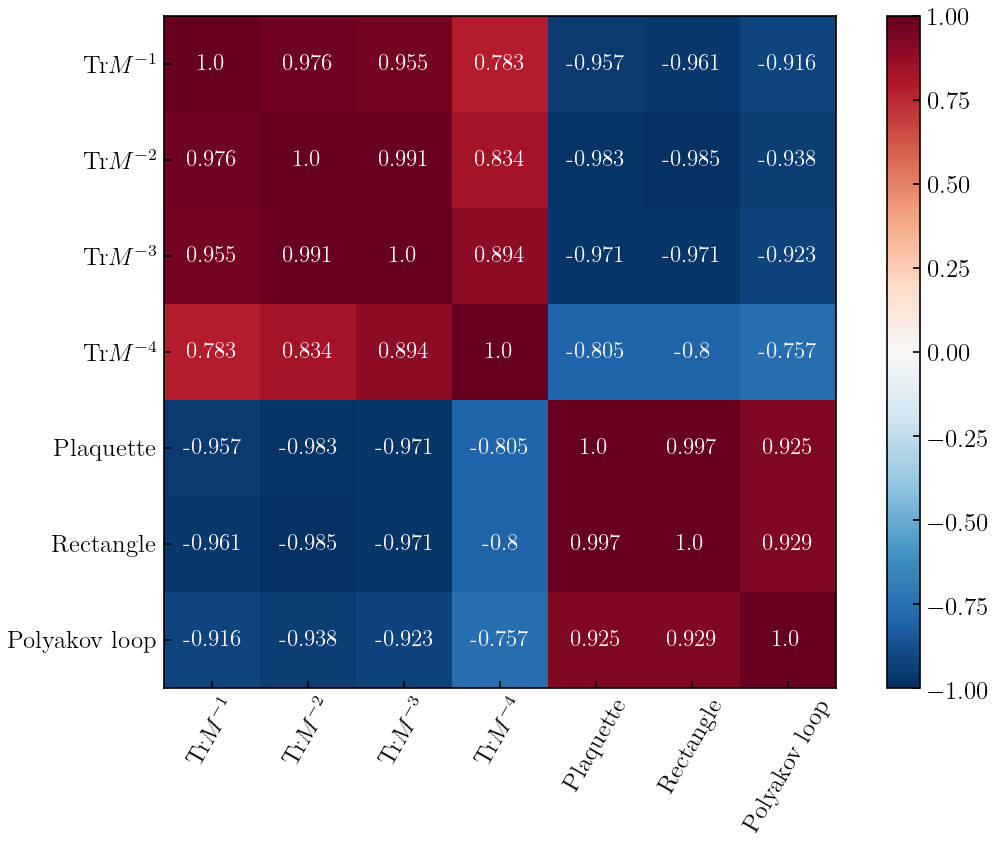

PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `/Users/benjamin/work/Deborah.jl/share/corr_L12T4b1.60k13575-crop.pdf'.
PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `/Users/benjamin/work/Deborah.jl/share/corr_L12T4b1.60k13577-crop.pdf'.
PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `/Users/benjamin/work/Deborah.jl/share/corr_L12T4b1.60k13580-crop.pdf'.
PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `/Users/benjamin/work/Deborah.jl/share/corr_L12T4b1.60k13582-crop.pdf'.
PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `/Users/benjamin/work/Deborah.jl/share/corr_L12T4b1.60k13585-crop.pdf'.


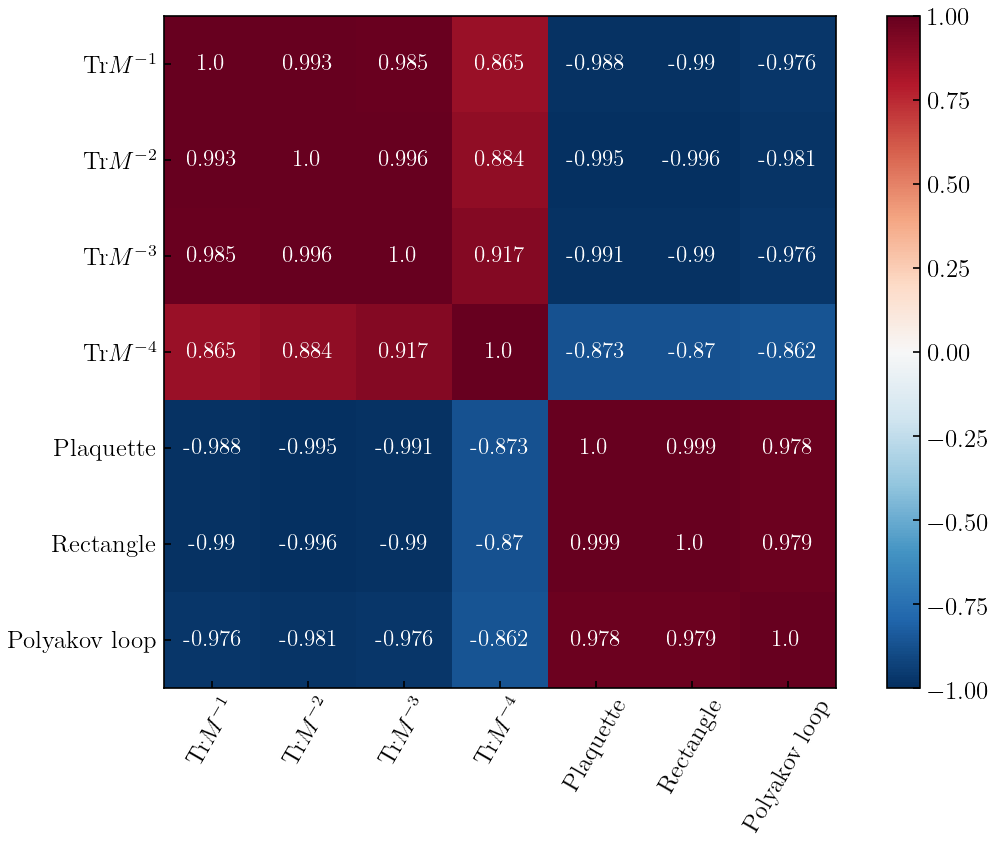

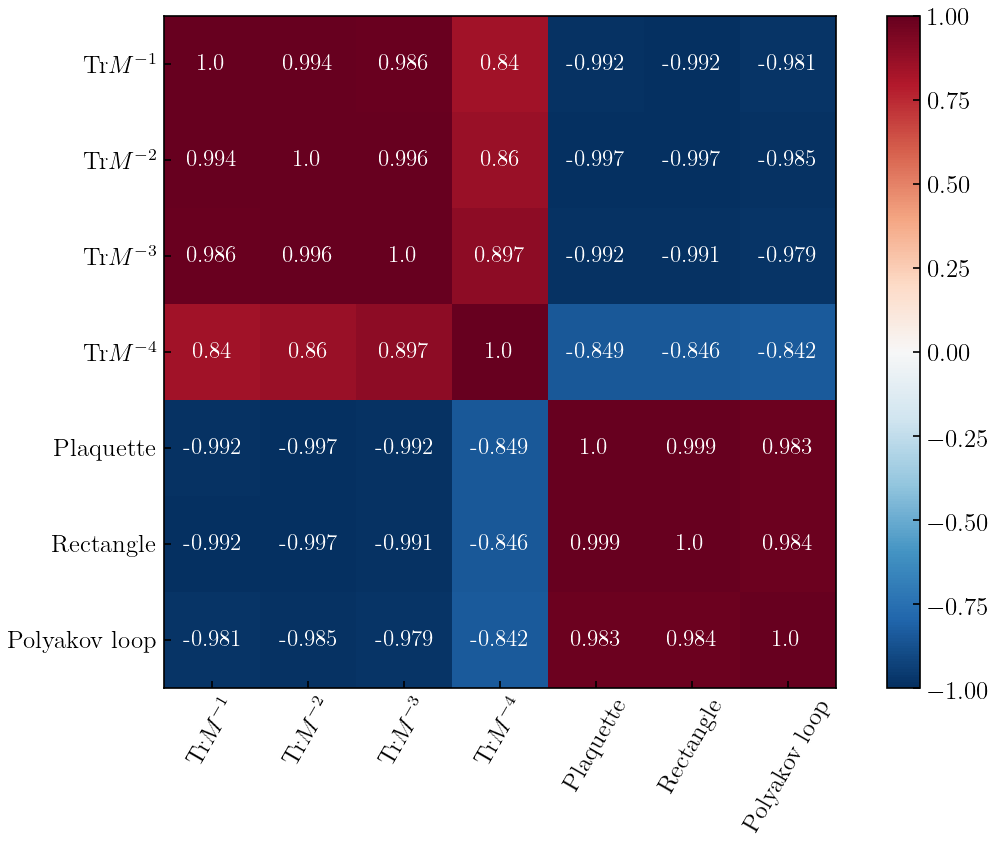

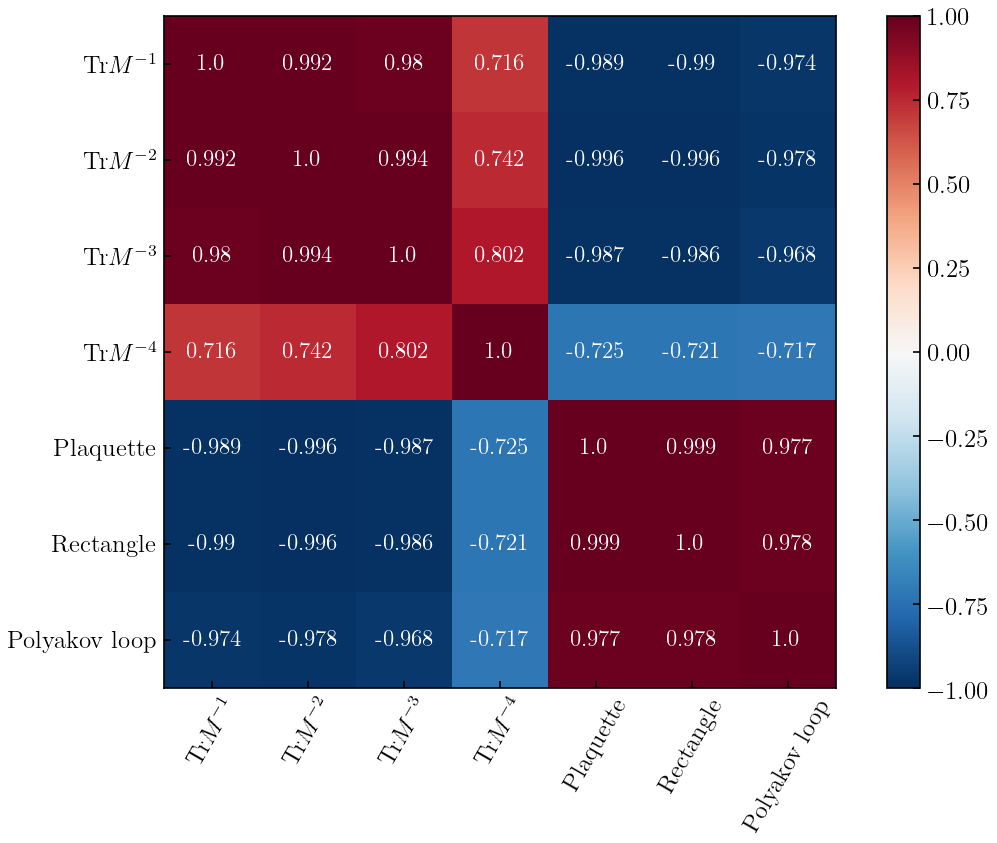

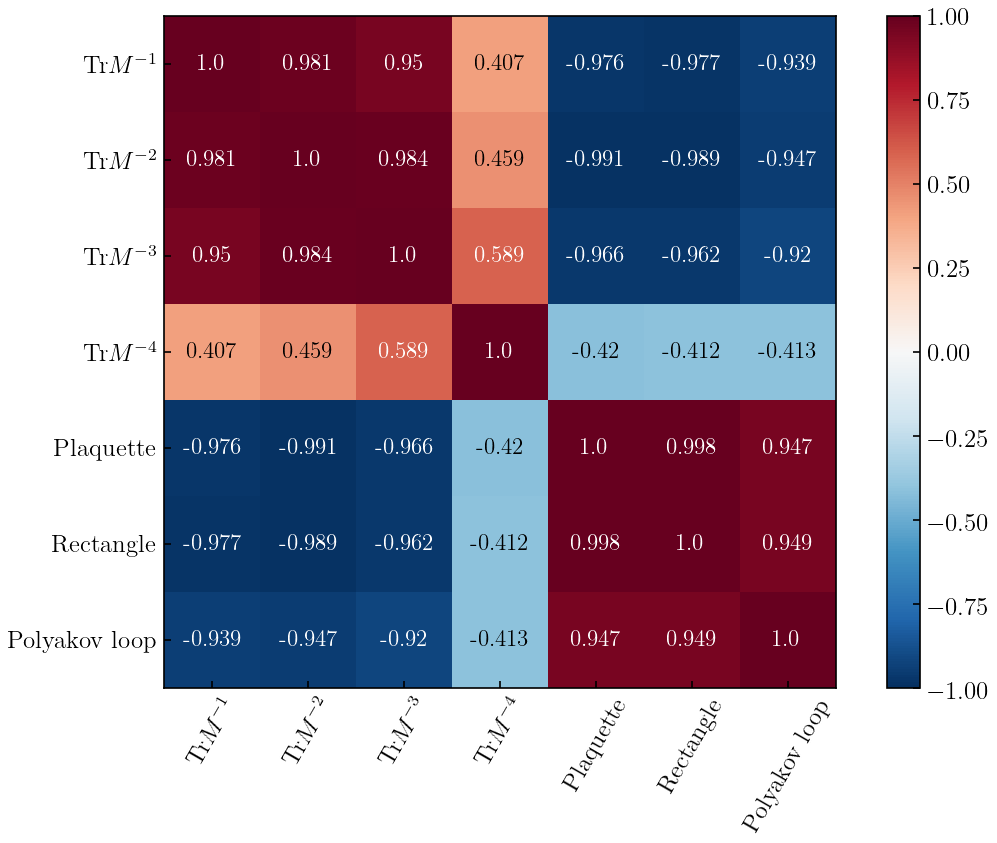

In [3]:
key = ["pbp", "trdinv2", "trdinv3", "trdinv4", "plaq", "rect", "ploop"];

key_doc = ["\$\\mathrm{Tr} M^{-1}\$", "\$\\mathrm{Tr} M^{-2}\$", "\$\\mathrm{Tr} M^{-3}\$", "\$\\mathrm{Tr} M^{-4}\$", "\$\\textrm{Plaquette}\$", "\$\\textrm{Rectangle}\$", "\\textrm{Polyakov loop}"]

# key = ["pbp", "trdinv2", "trdinv3", "trdinv4", "plaq", "rect"];

# key_doc = ["\$\\mathrm{Tr} M^{-1}\$", "\$\\mathrm{Tr} M^{-2}\$", "\$\\mathrm{Tr} M^{-3}\$", "\$\\mathrm{Tr} M^{-4}\$", "\$\\textrm{Plaquette}\$", "\$\\textrm{Rectangle}\$"]

Deborah.Rebekah.PyPlotLaTeX.set_pyplot_latex_style()
Deborah.Rebekah.PyPlotLaTeX.set_pyplot_latex_style_corrmat()

mats = [Deborah.Rahab.CorrPlot.build_observables(key, key_doc, p) for p in raw_paths]

# Calculate Pearson correlation coefficient between each observables.
for (mat, ens) in zip(mats, ensembles)
    Deborah.Rahab.CorrPlot.corrmat_plot(mat, key_doc, ens, PROJECT_ROOT*"/share"; save_file=true)
end